<a href="https://colab.research.google.com/github/kimgayeon430/IOT/blob/main/%EC%9D%B4%EC%83%81%EC%B9%98%ED%83%90%EC%A7%80_outlier_detection_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 이상치 탐지(Outlier Detection) 실습 교안
## Distance-based · Density-based · Matrix Factorization-based · Angle-based

> **실습 환경**: Google Colab (Python 3, scikit-learn + PyOD)

---

### 학습 목차
1. 환경 설정 및 실습 데이터 생성
2. 이상치 탐지 개요
3. **거리 기반 (Distance-based)** — k번째 최근접 이웃 거리
4. **밀도 기반 (Density-based)** — LOF (Local Outlier Factor)
5. **행렬 분해 기반 (Matrix Factorization-based)** — PCA 재구성 오차
6. **각도 기반 (Angle-based)** — ABOD (Angle-Based Outlier Detection)
7. 네 기법 종합 비교 (ROC-AUC · 결정 경계 시각화)
8. 정리 및 추가 과제

## 1. 환경 설정 및 실습 데이터 생성

이상치 탐지 전용 라이브러리 **PyOD**(Python Outlier Detection)를 설치합니다. 네 가지 기법(KNN, LOF, PCA, ABOD)을 모두 제공합니다.

In [1]:
!pip install -q pyod
print("PyOD 설치 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 762.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.4/411.4 kB 2.9 MB/s eta 0:00:00
PyOD 설치 완료


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.unicode_minus"] = False
RANDOM_STATE = 42
print("라이브러리 준비 완료")

라이브러리 준비 완료


### 실습 데이터: 2차원 합성 데이터

시각적으로 이해하기 쉽도록 **2차원 데이터**를 만듭니다.
- **정상치(inlier)**: 두 개의 군집(cluster)에 모여 있는 점들
- **이상치(outlier)**: 공간에 무작위로 흩어진 점들

정답 레이블(`y`)을 알고 있으므로 나중에 ROC-AUC로 각 기법의 성능을 객관적으로 비교할 수 있습니다.

In [3]:
from sklearn.datasets import make_blobs

rng = np.random.RandomState(RANDOM_STATE)

# 정상치: 2개 군집, 총 240개
X_in, _ = make_blobs(n_samples=240, centers=[[2, 2], [-2, -1]],
                     cluster_std=[0.6, 0.5], random_state=RANDOM_STATE)
# 이상치: 공간에 무작위로 흩뿌린 20개
X_out = rng.uniform(low=-6, high=6, size=(20, 2))

X = np.vstack([X_in, X_out])
y = np.r_[np.zeros(len(X_in)), np.ones(len(X_out))]   # 0=정상, 1=이상
n_outliers = int(y.sum())
contamination = n_outliers / len(y)

print("전체 {}개 | 정상 {}개 | 이상 {}개 | 오염도(contamination) {:.3f}".format(
    len(X), len(X_in), n_outliers, contamination))

전체 260개 | 정상 240개 | 이상 20개 | 오염도(contamination) 0.077


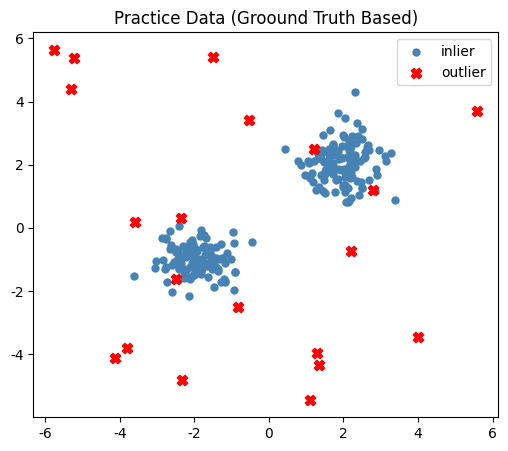

In [4]:
# 데이터 시각화 (정답 기준)
plt.scatter(X[y==0, 0], X[y==0, 1], c="steelblue", s=25, label="inlier")
plt.scatter(X[y==1, 0], X[y==1, 1], c="red", s=55, marker="X", label="outlier")
plt.title("Practice Data (Groound Truth Based)")
plt.legend(); plt.show()

## 2. 이상치 탐지 개요

**이상치(Outlier/Anomaly)** 란 대다수 데이터와 뚜렷이 다른 패턴을 보이는 관측치입니다. 사기 거래, 장비 고장, 침입 탐지, 품질 불량 등 실무에서 매우 중요합니다.

탐지 접근법은 *"무엇으로 비정상을 정의하는가"* 에 따라 나뉩니다.

| 접근법 | 비정상의 정의 | 대표 기법 | 핵심 직관 |
|--------|---------------|-----------|-----------|
| **거리 기반** | 이웃이 멀다 | k-NN 거리 | 주변에 가까운 점이 없으면 이상 |
| **밀도 기반** | 주변 밀도가 낮다 | LOF | *상대적* 밀도가 이웃보다 낮으면 이상 |
| **행렬 분해 기반** | 저차원 구조로 복원 안 됨 | PCA 재구성 | 데이터의 주된 패턴에서 벗어나면 이상 |
| **각도 기반** | 방향 분산이 작다 | ABOD | 다른 점들이 한쪽에 몰려 보이면 이상 |

> **공통 출력**: 대부분의 기법은 각 점에 **이상 점수(anomaly score)** 를 부여하고, 상위 일부를 이상치로 분류합니다. PyOD에서는 `decision_scores_`(점수, 클수록 비정상)와 `labels_`(0/1)로 제공됩니다.

## 3. 거리 기반 이상치 탐지 (Distance-based)

### 개념
- 가장 직관적인 방법입니다. **이웃과 멀리 떨어진 점**을 이상치로 봅니다.
- 대표 척도는 **k번째 최근접 이웃까지의 거리**(k-th NN distance)입니다. 이 거리가 클수록 주변이 비어 있다는 뜻이므로 이상 점수가 높습니다.
- 고전적 정의(Knorr & Ng의 DB(p, D)-outlier): *전체의 비율 p 이상이 거리 D보다 멀리 있으면 이상치*. 실무에서는 k번째 거리 방식이 널리 쓰입니다.
- **장점**: 단순·직관적. **단점**: 밀도가 다른 군집이 섞이면 부정확, 차원이 높으면 거리 의미가 약해짐(차원의 저주), 스케일 민감.

#### (1) 원리 직접 구현 — k번째 최근접 이웃 거리

In [5]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

k = 10
# n_neighbors=k+1 : 첫 번째 이웃은 자기 자신(거리 0)이므로 +1
nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
distances, _ = nn.kneighbors(X)

# 자기 자신을 제외한 k번째 이웃까지의 거리 = 마지막 열
kth_distance = distances[:, -1]

# 거리가 큰 상위 n_outliers개를 이상치로 판정
threshold = np.sort(kth_distance)[-n_outliers]
manual_pred = (kth_distance >= threshold).astype(int)

print("Recall   : {:.3f}".format(recall_score(y, manual_pred)))
print("Precision: {:.3f}".format(precision_score(y, manual_pred)))
print("F1-score : {:.3f}".format(f1_score(y, manual_pred)))
auc = roc_auc_score(y, kth_distance)
print("직접 구현 k-NN 거리 ROC-AUC: {:.3f}".format(auc))

Recall   : 0.800
Precision: 0.800
F1-score : 0.800
직접 구현 k-NN 거리 ROC-AUC: 0.965


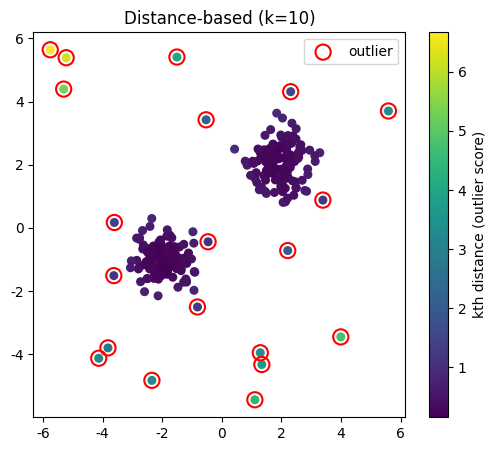

In [6]:
# 이상 점수(거리)를 색으로 표현
plt.scatter(X[:, 0], X[:, 1], c=kth_distance, cmap="viridis", s=30)
plt.colorbar(label="kth distance (outlier score)")
plt.scatter(X[manual_pred==1, 0], X[manual_pred==1, 1],
            facecolors="none", edgecolors="red", s=120, linewidths=1.5,
            label="outlier")
plt.title("Distance-based (k=10)")
plt.legend(); plt.show()

#### (2) 고전적 정의 — DB(p, D)-outlier (Knorr & Ng)

어떤 점 $x$가 전체 데이터의 $p$ 이상되는 점들과 거리 $D$ 보다 멀리 떨어져 있다면 이상치로 간주하는 방법입니다. 즉, $x$를 제외한 전체 데이터 중, $x$로부터 거리 $D$ 이상 떨어진 점들의 비율이 $p$를 넘으면 $x$는 이상치입니다.

In [7]:
from sklearn.neighbors import NearestNeighbors

# 파라미터 설정
p_threshold = 0.1  # 전체 데이터의 10% 이상이 D보다 멀리 있을 때 이상치
D_distance = 1.0   # 거리 D

db_outlier_scores = []

for i in range(len(X)):
    # 현재 점을 제외한 나머지 점들과의 거리 계산
    distances_to_others = np.linalg.norm(X - X[i], axis=1)
    # 자기 자신과의 거리는 0이므로 제외
    distances_to_others = np.delete(distances_to_others, i)

    # 거리 D보다 멀리 있는 점들의 개수 계산
    num_far_points = np.sum(distances_to_others > D_distance)

    # 멀리 있는 점들의 비율 계산
    proportion_far = num_far_points / (len(X) - 1)

    # 이 비율이 p_threshold보다 크거나 같으면 높은 점수 부여 (이상치일 가능성 높음)
    # 여기서는 간단히 proportion_far 자체를 점수로 사용 (클수록 이상치)
    db_outlier_scores.append(proportion_far)

db_outlier_scores = np.array(db_outlier_scores)

# 이상치 임계값 설정 (상위 n_outliers개를 이상치로 판정)
threshold_db = np.sort(db_outlier_scores)[-n_outliers]
db_pred = (db_outlier_scores >= threshold_db).astype(int)

print("Recall   : {:.3f}".format(recall_score(y, db_pred)))
print("Precision: {:.3f}".format(precision_score(y, db_pred)))
print("F1-score : {:.3f}".format(f1_score(y, db_pred)))
auc_db = roc_auc_score(y, db_outlier_scores)
print("DB(p, D)-outlier ROC-AUC: {:.3f}".format(auc_db))

Recall   : 0.800
Precision: 0.800
F1-score : 0.800
DB(p, D)-outlier ROC-AUC: 0.964


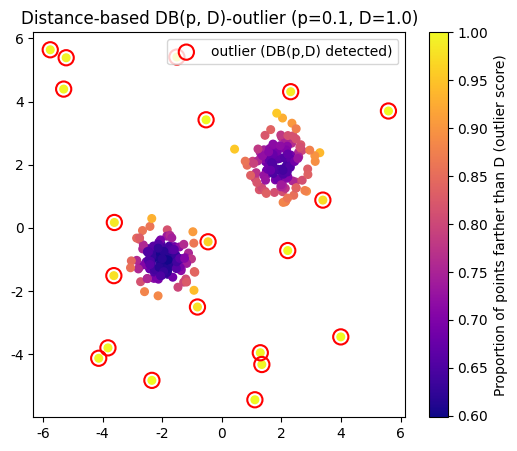

In [8]:
# DB(p, D)-outlier 점수를 색으로 표현
plt.scatter(X[:, 0], X[:, 1], c=db_outlier_scores, cmap="plasma", s=30)
plt.colorbar(label="Proportion of points farther than D (outlier score)")
plt.scatter(X[db_pred==1, 0], X[db_pred==1, 1],
            facecolors="none", edgecolors="red", s=120, linewidths=1.5,
            label="outlier (DB(p,D) detected)")
plt.title("Distance-based DB(p, D)-outlier (p={}, D={})".format(p_threshold, D_distance))
plt.legend(); plt.show()

## 4. 밀도 기반 이상치 탐지 (Density-based)

### 개념 — LOF (Local Outlier Factor)
- 거리 기반의 약점(밀도가 다른 군집 처리)을 보완합니다. **절대 거리가 아니라 *상대적* 밀도**를 봅니다.
- 핵심 아이디어: 한 점의 밀도를 **그 이웃들의 밀도와 비교**합니다.
  - 이웃들과 밀도가 비슷하면 → LOF ≈ 1 (정상)
  - 이웃들보다 자신의 밀도가 훨씬 낮으면 → LOF ≫ 1 (이상)
- 이를 통해 **빽빽한 군집 근처의 점**과 **드문드문한 군집 안의 점**을 공정하게 비교할 수 있습니다.
- 계산: 도달가능거리(reachability distance) → 국소도달밀도(LRD) → 이웃 LRD와의 비율(LOF).

#### (1) 라이브러리 실습 — scikit-learn LocalOutlierFactor

In [9]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

lof_sk = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
pred_raw = lof_sk.fit_predict(X)          # -1=이상, 1=정상
# pred_raw를 y와 동일한 0/1 형식으로 변환 (0=정상, 1=이상)
pred_sk = (pred_raw == -1).astype(int)

# negative_outlier_factor_: 값이 작을수록(음수로 클수록) 비정상 → 부호 반전해 점수화
lof_score = -lof_sk.negative_outlier_factor_

print("Recall   : {:.3f}".format(recall_score(y, pred_sk)))
print("Precision: {:.3f}".format(precision_score(y, pred_sk)))
print("F1-score : {:.3f}".format(f1_score(y, pred_sk)))
print("sklearn LOF ROC-AUC: {:.3f}".format(roc_auc_score(y, lof_score)))

Recall   : 0.800
Precision: 0.800
F1-score : 0.800
sklearn LOF ROC-AUC: 0.965


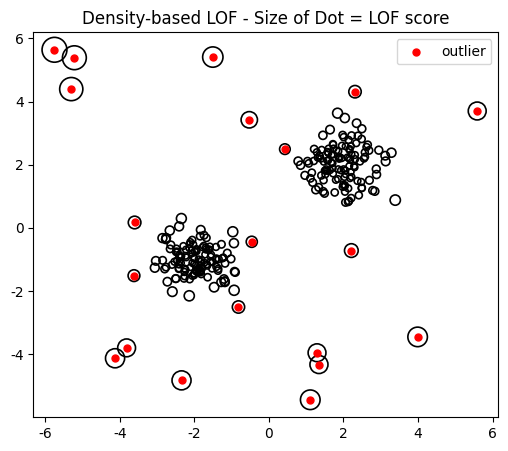

In [10]:
# LOF 점수를 점 크기로 표현 (클수록 이상 의심)
size = 20 + (lof_score - lof_score.min()) / (np.ptp(lof_score)) * 300
plt.scatter(X[:, 0], X[:, 1], s=size, edgecolors="k",
            facecolors="none", linewidths=1.2)
plt.scatter(X[pred_sk==1, 0], X[pred_sk==1, 1], c="red", s=25,
            label="outlier")
plt.title("Density-based LOF - Size of Dot = LOF score")
plt.legend(); plt.show()

## 5. 행렬 분해 기반 이상치 탐지 (Matrix Factorization-based)

### 개념 — PCA 재구성 오차
- 데이터 행렬 $X$를 **저차원(저계수, low-rank) 구조로 근사**한 뒤, 원본과 얼마나 다른지로 이상을 판단합니다.
- PCA는 SVD(특이값 분해)를 통해 $X \approx U_k \Sigma_k V_k^\top$ 형태의 **행렬 분해**를 수행합니다. 상위 $k$개 주성분이 데이터의 **주된 패턴**을 담습니다.
- 정상치는 이 주된 패턴으로 잘 복원되지만, **이상치는 패턴에서 벗어나 재구성 오차(reconstruction error)가 큽니다**.
- 고차원 데이터에서 특히 유용하며, 노이즈에 강건합니다.

#### (1) 원리 직접 구현 — PCA 재구성 오차

In [11]:
from sklearn.decomposition import PCA

# 표준화 후 PCA (행렬 분해 기반은 스케일 영향이 큼)
Xs = StandardScaler().fit_transform(X)

n_comp = 1                                  # 2D 데이터를 1개 주성분으로 근사
pca = PCA(n_components=n_comp)
X_proj = pca.fit_transform(Xs)              # 저차원으로 투영 (분해)
X_recon = pca.inverse_transform(X_proj)     # 다시 원래 차원으로 복원

# 재구성 오차 = 원본과 복원본의 거리 제곱
recon_error = np.sum((Xs - X_recon) ** 2, axis=1)
thr = np.sort(recon_error)[-n_outliers]
mf_pred = (recon_error >= thr).astype(int)

print("Recall   : {:.3f}".format(recall_score(y, mf_pred)))
print("Precision: {:.3f}".format(precision_score(y, mf_pred)))
print("F1-score : {:.3f}".format(f1_score(y, mf_pred)))
print("직접 구현 PCA 재구성 오차 ROC-AUC: {:.3f}".format(roc_auc_score(y, recon_error)))
print("1개 주성분이 설명하는 분산 비율: {:.1%}".format(pca.explained_variance_ratio_[0]))

Recall   : 0.800
Precision: 0.800
F1-score : 0.800
직접 구현 PCA 재구성 오차 ROC-AUC: 0.922
1개 주성분이 설명하는 분산 비율: 82.0%


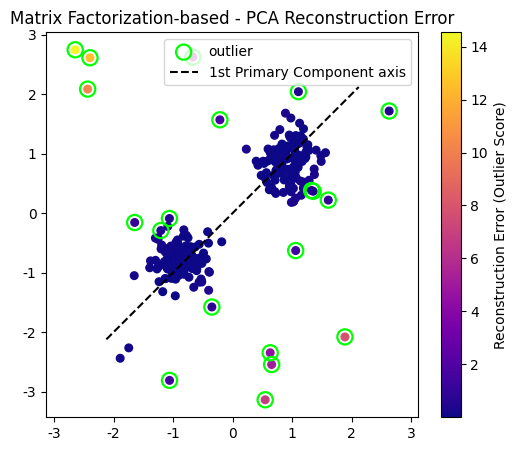

In [12]:
# 주성분 축(주된 패턴)과 재구성 오차 시각화
plt.scatter(Xs[:, 0], Xs[:, 1], c=recon_error, cmap="plasma", s=30)
plt.colorbar(label="Reconstruction Error (Outlier Score)")
plt.scatter(Xs[mf_pred==1, 0], Xs[mf_pred==1, 1],
            facecolors="none", edgecolors="lime", s=120, linewidths=1.6,
            label="outlier")
# 1번 주성분 방향 직선 표시
v = pca.components_[0]
t = np.linspace(-3, 3, 10)
plt.plot(t*v[0], t*v[1], "k--", lw=1.5, label="1st Primary Component axis")
plt.title("Matrix Factorization-based - PCA Reconstruction Error")
plt.legend(); plt.axis("equal"); plt.show()

## 6. 각도 기반 이상치 탐지 (Angle-based, ABOD)

### 개념 — ABOD (Angle-Based Outlier Detection)
- 고차원에서 거리의 변별력이 약해지는 **차원의 저주**에 강건하도록 고안된 기법입니다 (Kriegel et al., 2008).
- 핵심 직관: 어떤 점 $p$에서 다른 모든 점 쌍 $(a, b)$을 바라본 **각도의 분산**을 봅니다.
  - **정상치**(군집 내부): 주변 점들이 사방에 있어 각도가 다양 → **분산이 큼**
  - **이상치**(군집 외곽): 다른 점들이 대부분 한쪽 방향에 몰려 보임 → **각도 분산이 작음**
- 점수: **ABOF**(Angle-Based Outlier Factor) = 거리로 가중한 각도들의 분산. 값이 **작을수록 이상**입니다.
- PyOD에서는 부호를 맞춰 `decision_scores_`가 **클수록 비정상**이 되도록 처리합니다.

#### (1) 직관 확인 — 정상치 vs 이상치의 각도 분산 비교

In [13]:
def abof(p_idx, X):
    """한 점에서 본 (다른 점 쌍) 각도들의 가중 분산(ABOF)을 직접 계산."""
    p = X[p_idx]
    others = np.delete(X, p_idx, axis=0)
    vecs = others - p                       # p에서 다른 점들로 향하는 벡터
    norms = np.linalg.norm(vecs, axis=1)
    weighted_angles = []
    n = len(vecs)
    for i in range(n):
        for j in range(i + 1, n):
            denom = (norms[i] ** 2) * (norms[j] ** 2)
            if denom == 0:
                continue
            cos_a = np.dot(vecs[i], vecs[j]) / (norms[i] * norms[j])
            # 거리로 가중한 각도 값
            weighted_angles.append(cos_a / denom)
    return np.var(weighted_angles)

# 전형적 정상치(군집 중심 근처)와 이상치(외곽) 한 점씩 골라 비교
inlier_idx = np.argmin(np.linalg.norm(X - X_in.mean(axis=0), axis=1))
outlier_idx = len(X_in) + 0   # 첫 번째 이상치

print("정상치 한 점의 ABOF(각도 분산): {:.3e}  → 큼".format(abof(inlier_idx, X)))
print("이상치 한 점의 ABOF(각도 분산): {:.3e}  → 작음".format(abof(outlier_idx, X)))
print("\n→ 이상치는 다른 점들이 한쪽에 몰려 보여 각도 분산이 작습니다.")

정상치 한 점의 ABOF(각도 분산): 3.449e-02  → 큼
이상치 한 점의 ABOF(각도 분산): 7.672e-07  → 작음

→ 이상치는 다른 점들이 한쪽에 몰려 보여 각도 분산이 작습니다.


#### (2) 라이브러리 실습 — PyOD ABOD

In [14]:
from pyod.models.abod import ABOD
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

# n_neighbors를 쓰는 'fast' 방식(기본)으로 계산 비용 절감
abod = ABOD(n_neighbors=15, contamination=contamination, method="fast")
abod.fit(X)

print("Recall   : {:.3f}".format(recall_score(y, abod.labels_)))
print("Precision: {:.3f}".format(precision_score(y, abod.labels_)))
print("F1-score : {:.3f}".format(f1_score(y, abod.labels_)))
print("PyOD ABOD ROC-AUC: {:.3f}".format(roc_auc_score(y, abod.decision_scores_)))
print("탐지된 이상치 수:", int(abod.labels_.sum()))

Recall   : 0.800
Precision: 0.800
F1-score : 0.800
PyOD ABOD ROC-AUC: 0.925
탐지된 이상치 수: 20


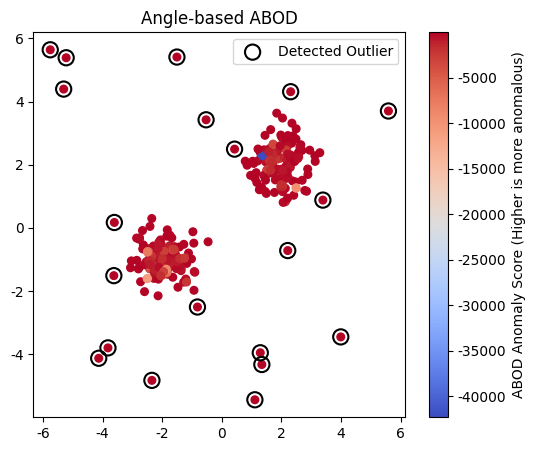

In [15]:
# ABOD 이상 점수 시각화
plt.scatter(X[:, 0], X[:, 1], c=abod.decision_scores_, cmap="coolwarm", s=30)
plt.colorbar(label="ABOD Anomaly Score (Higher is more anomalous)")
plt.scatter(X[abod.labels_==1, 0], X[abod.labels_==1, 1],
            facecolors="none", edgecolors="black", s=120, linewidths=1.5,
            label="Detected Outlier")
plt.title("Angle-based ABOD")
plt.legend(); plt.show()

**해석 포인트**
- ABOD는 **고차원**에서 거리/밀도 기반보다 강건한 경향이 있습니다.
- 정확한 ABOD는 모든 점 쌍을 보므로 $O(n^3)$로 느립니다. 대용량에는 `method="fast"`(이웃만 사용)나 `FastABOD`를 사용합니다.

## 7. 네 기법 종합 비교

동일한 데이터에 네 가지 기법을 적용하여 **ROC-AUC**와 **결정 경계(이상 점수 등고선)** 를 함께 비교합니다.

In [16]:
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.pca import PCA as PCA_OD
from pyod.models.abod import ABOD

detectors = {
    "Distance-based (KNN)":        KNN(n_neighbors=10, contamination=contamination),
    "Density-based (LOF)":        LOF(n_neighbors=20, contamination=contamination),
    "Matrix Factorization-based (PCA)":    PCA_OD(contamination=contamination),
    "Angle-based (ABOD)":       ABOD(n_neighbors=15, contamination=contamination, method="fast"),
}

results = {}
for name, det in detectors.items():
    det.fit(X)
    results[name] = roc_auc_score(y, det.decision_scores_)
    print("{:28s} ROC-AUC = {:.3f}".format(name, results[name]))

Distance-based (KNN)         ROC-AUC = 0.965
Density-based (LOF)          ROC-AUC = 0.965
Matrix Factorization-based (PCA) ROC-AUC = 0.813
Angle-based (ABOD)           ROC-AUC = 0.925


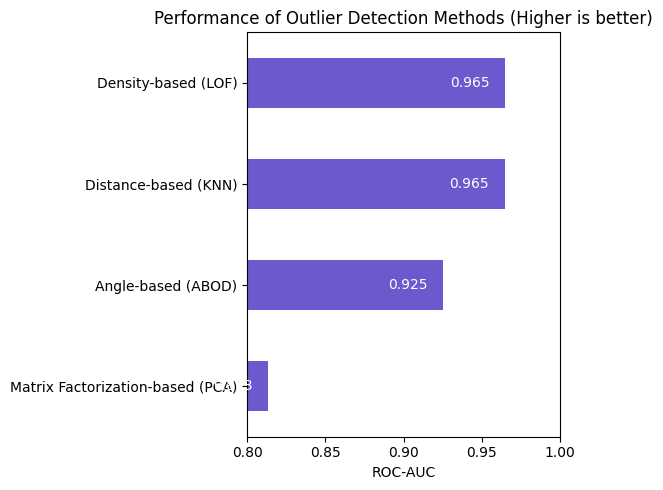

In [17]:
# ROC-AUC 막대 비교
s = pd.Series(results).sort_values()
s.plot(kind="barh", color="slateblue")
plt.xlabel("ROC-AUC"); plt.title("Performance of Outlier Detection Methods (Higher is better)")
plt.xlim(0.8, 1.0)
for i, v in enumerate(s.values):
    plt.text(v - 0.01, i, "{:.3f}".format(v), va="center", ha="right", color="white")
plt.tight_layout(); plt.show()

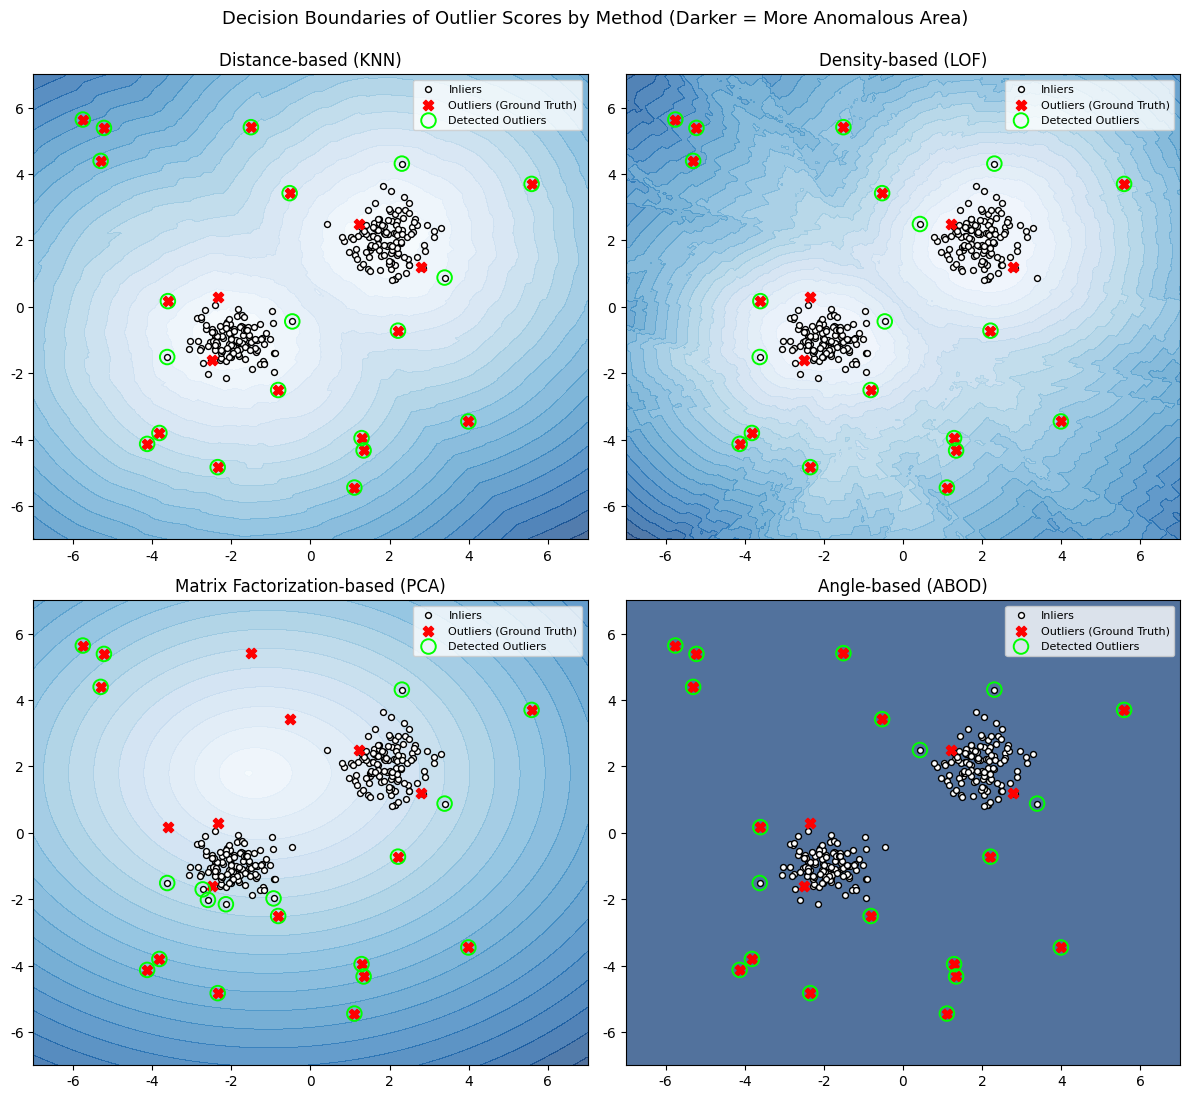

In [18]:
# Visualize decision boundaries (outlier score contours) - compare how each method partitions the space
xx, yy = np.meshgrid(np.linspace(-7, 7, 200), np.linspace(-7, 7, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, (name, det) in zip(axes.ravel(), detectors.items()):
    try:
        Z = det.decision_function(grid).reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=20, cmap="Blues", alpha=0.7)
    except Exception as e:
        pass  # Some models may have limitations on evaluating arbitrary points
    ax.scatter(X[y==0,0], X[y==0,1], c="white", edgecolors="k", s=18, label="Inliers")
    ax.scatter(X[y==1,0], X[y==1,1], c="red", marker="X", s=55, label="Outliers (Ground Truth)")
    ax.scatter(X[det.labels_==1,0], X[det.labels_==1,1],
               facecolors="none", edgecolors="lime", s=110, linewidths=1.4, label="Detected Outliers")
    ax.set_title(name); ax.legend(loc="upper right", fontsize=8)
plt.suptitle("Decision Boundaries of Outlier Scores by Method (Darker = More Anomalous Area)", y=0.995, fontsize=13)
plt.tight_layout(); plt.show()

**해석 포인트**
- 등고선의 **진한 영역(=이상 점수 높음)** 모양이 기법마다 다릅니다.
  - 거리/밀도 기반: 군집 주변을 감싸는 형태
  - PCA(행렬분해): 주성분 축에서 멀어질수록 비정상 → 축 방향으로 늘어진 형태
  - ABOD: 군집 외곽의 각도 분산 차이를 반영
- **정답이 없는 실제 데이터**에서는 ROC-AUC를 쓸 수 없으므로, 도메인 지식·여러 기법의 **합의(ensemble)**·시각화로 판단합니다.

## 8. 정리 및 추가 과제

### 기법 요약

| 기법 | 비정상 정의 | 강점 | 약점 |
|------|-------------|------|------|
| **거리 기반 (KNN)** | k번째 이웃이 멀다 | 단순·직관적 | 밀도 차이·고차원에 약함, 스케일 민감 |
| **밀도 기반 (LOF)** | 이웃 대비 밀도가 낮다 | 밀도 다른 군집 처리 우수 | `n_neighbors`에 민감, 고차원 약화 |
| **행렬분해 기반 (PCA)** | 저차원 구조로 복원 안 됨 | 고차원·노이즈에 강건, 빠름 | 비선형 패턴엔 한계(→오토인코더) |
| **각도 기반 (ABOD)** | 각도 분산이 작다 | 고차원에 강건 | 계산량 큼(O(n³)), fast 버전 필요 |

### 실무 팁
- 거리/밀도/각도 기반은 모두 **스케일에 민감** → 적용 전 표준화 권장
- 단일 기법에 의존하지 말고 **여러 기법을 함께 적용**해 교차 검증
- PyOD의 통일된 인터페이스(`fit` → `decision_scores_`, `labels_`)로 기법 교체가 쉽습니다
- 정답 레이블이 없으면 ROC-AUC 대신 **점수 분포·시각화·도메인 검증**에 의존

> 수고하셨습니다! 각 셀의 `k`, `n_neighbors`, `n_components`, `contamination` 값을 바꿔가며 결과가 어떻게 달라지는지 직접 실험하는 것이 가장 좋은 학습입니다.